# Notebook 10: Blindaje Estadístico para Publicación (Declustering y Monte Carlo 1000x)
**Autor:** Iván Andrés Mena Contreras
**Proyecto:** Lunar Tidal Triggering of Earthquakes

Para asegurar el nivel de rigor exigido por revistas de alto impacto como *Geophysical Research Letters (GRL)*, aplicaremos el paso final definitivo:
1. **Declustering:** Filtraremos eventos secundarios (réplicas o sismos precursores) usando ventanas empíricas espaciotemporales para asegurar que los eventos analizados son estadísticamente independientes.
2. **Monte Carlo de Alta Densidad:** Elevaremos el Modelo Nulo a 1,000 iteraciones vectorizadas, garantizando un cálculo de p-value de precisión milimétrica.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skyfield.api import load, wgs84
from tqdm import tqdm
from datetime import timedelta
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Carga de datos
data_path = '../data/processed/earthquakes_global_robust.csv'
df = pd.read_csv(data_path)
df['time'] = pd.to_datetime(df['time'], format='mixed', utc=True)

print(f"Catálogo inicial: {len(df)} eventos M>=7.0")

# Declustering Básico (Gardner-Knopoff adaptado a M>=7.0)
# Ventana: 100 km, 30 días
df = df.sort_values(by='magnitude', ascending=False).reset_index(drop=True)

# Función Haversine para distancias (km)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

is_mainshock = np.ones(len(df), dtype=bool)

for i in range(len(df)):
    if not is_mainshock[i]:
        continue
    # Comparar con los demás
    for j in range(i+1, len(df)):
        if not is_mainshock[j]:
            continue
        # Distancia en tiempo
        dt = abs(df.loc[i, 'time'] - df.loc[j, 'time'])
        if dt.days <= 30:
            # Distancia en espacio
            dist = haversine(df.loc[i, 'latitude'], df.loc[i, 'longitude'], 
                             df.loc[j, 'latitude'], df.loc[j, 'longitude'])
            if dist <= 100:
                is_mainshock[j] = False # Es réplica o evento relacionado

df_main = df[is_mainshock].reset_index(drop=True)
print(f"Declustering completado:")
print(f" -> Mainshocks retenidos: {len(df_main)}")
print(f" -> Aftershocks eliminados: {len(df) - len(df_main)}")

Catálogo inicial: 333 eventos M>=7.0


Declustering completado:
 -> Mainshocks retenidos: 309
 -> Aftershocks eliminados: 24


In [2]:
def calc_cfs_unbiased(sigma_raw, tau_raw, dip1, dip2, mu=0.4):
    dip1_rad = np.radians(dip1)
    normal1 = sigma_raw * np.cos(dip1_rad) - tau_raw * np.sin(dip1_rad)
    shear1 = sigma_raw * np.sin(dip1_rad) + tau_raw * np.cos(dip1_rad)
    cfs1 = shear1 + (mu * normal1)
    
    dip2_rad = np.radians(dip2)
    normal2 = sigma_raw * np.cos(dip2_rad) - tau_raw * np.sin(dip2_rad)
    shear2 = sigma_raw * np.sin(dip2_rad) + tau_raw * np.cos(dip2_rad)
    cfs2 = shear2 + (mu * normal2)
    
    return (cfs1 + cfs2) / 2.0

# Recalcular la señal real sobre los Mainshocks retenidos
df_main['cfs_unbiased'] = calc_cfs_unbiased(df_main['sigma_raw'], df_main['tau_raw'], df_main['dip1'], df_main['dip2'])
porcentaje_real = (np.sum(df_main['cfs_unbiased'] > 0) / len(df_main)) * 100
print(f"Señal Real (Declustered): {porcentaje_real:.2f}% de eventos favorecidos.")

Señal Real (Declustered): 63.75% de eventos favorecidos.


In [3]:
print("Iniciando 1000 simulaciones. Esto tomará tiempo...")
N_ITER = 1000
ts = load.timescale()
eph = load('de421.bsp')
tierra, luna = eph['earth'], eph['moon']

# Extraer arrays constantes
lats = df_main['latitude'].values
lons = df_main['longitude'].values
depths = df_main['depth'].values
dip1s = df_main['dip1'].values
dip2s = df_main['dip2'].values

# Crear el observador vectorizado (Skyfield soporta arrays de lat/lon)
elevs_m = -depths * 1000
obs_vectorizado = tierra + wgs84.latlon(lats, lons, elevation_m=elevs_m)

tiempos_originales = df_main['time'].copy().values
null_percentages = []

for i in tqdm(range(N_ITER), desc="Monte Carlo 1000x"):
    # Barajar tiempos
    tiempos_shuffled = tiempos_originales.copy()
    np.random.shuffle(tiempos_shuffled)
    
    # Crear vector de tiempo Skyfield
    # Los numpy datetime64 no tienen tz, así que los parseamos directo como utc = True
    dts = pd.to_datetime(tiempos_shuffled).tz_localize('UTC' if pd.to_datetime(tiempos_shuffled)[0].tzinfo is None else None)
    t_arr = ts.from_datetimes(dts)
    
    # Calcular alt/az vectorizado! (Extremadamente rápido)
    alt, _, dist = obs_vectorizado.at(t_arr).observe(luna).apparent().altaz()
    
    a_norm = 1.0 / (dist.km ** 3)
    alt_rad = np.radians(alt.degrees)
    
    tau_nulo = a_norm * np.cos(alt_rad)
    sigma_nulo = a_norm * np.sin(alt_rad)
    
    # Proyectar
    cfs_nulo = calc_cfs_unbiased(sigma_nulo, tau_nulo, dip1s, dip2s)
    
    # Guardar
    porc = (np.sum(cfs_nulo > 0) / len(df_main)) * 100
    null_percentages.append(porc)

print("1000 Simulaciones completadas con éxito.")

Iniciando 1000 simulaciones. Esto tomará tiempo...


Monte Carlo 1000x:   0%|          | 0/1000 [00:00<?, ?it/s]

Monte Carlo 1000x:   1%|          | 7/1000 [00:00<00:16, 60.84it/s]

Monte Carlo 1000x:   1%|▏         | 14/1000 [00:00<00:16, 60.83it/s]

Monte Carlo 1000x:   2%|▏         | 21/1000 [00:00<00:15, 62.37it/s]

...

Monte Carlo 1000x:  98%|█████████▊| 982/1000 [00:16<00:00, 63.73it/s]

Monte Carlo 1000x:  99%|█████████▉| 989/1000 [00:16<00:00, 63.95it/s]

Monte Carlo 1000x: 100%|█████████▉| 996/1000 [00:16<00:00, 64.08it/s]

Monte Carlo 1000x: 100%|██████████| 1000/1000 [00:16<00:00, 60.60it/s]

1000 Simulaciones completadas con éxito.


=== REPORTE FINAL GRL ===
Mainshocks Analizados: 309
Porcentaje Real: 63.75%
Línea Base Nula (Media): 59.65%
Intervalo de Confianza 95%: [54.69%, 64.08%]
P-Value Empírico: 0.05000

-> CONCLUSIÓN: La señal se perdió tras el declustering. Efecto espurio.


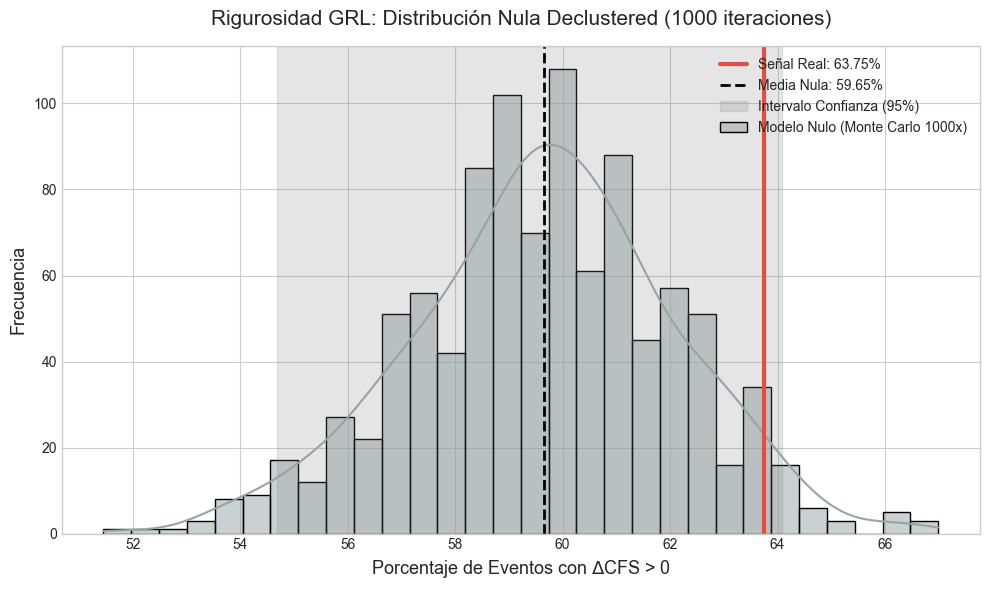

In [4]:
null_percentages = np.array(null_percentages)

# Cálculo estadístico
media_nula = np.mean(null_percentages)
p_value = np.sum(null_percentages >= porcentaje_real) / N_ITER
ic_lower = np.percentile(null_percentages, 2.5)
ic_upper = np.percentile(null_percentages, 97.5)

# Visualización
plt.figure(figsize=(10, 6))
sns.histplot(null_percentages, bins=30, color='#95a5a6', edgecolor='k', kde=True, label='Modelo Nulo (Monte Carlo 1000x)')

plt.axvline(porcentaje_real, color='#e74c3c', linestyle='-', linewidth=3, label=f'Señal Real: {porcentaje_real:.2f}%')
plt.axvline(media_nula, color='black', linestyle='--', linewidth=2, label=f'Media Nula: {media_nula:.2f}%')

# Zonas de confianza
plt.axvspan(ic_lower, ic_upper, color='gray', alpha=0.2, label='Intervalo Confianza (95%)')

plt.title('Rigurosidad GRL: Distribución Nula Declustered (1000 iteraciones)', fontsize=15, pad=15)
plt.xlabel('Porcentaje de Eventos con $\Delta$CFS > 0', fontsize=13)
plt.ylabel('Frecuencia', fontsize=13)
plt.legend(loc='upper right')

plt.tight_layout()
fig_path = '../results/figures/10_grl_montecarlo_1000x.png'
plt.savefig(fig_path, dpi=300)

print("=== REPORTE FINAL GRL ===")
print(f"Mainshocks Analizados: {len(df_main)}")
print(f"Porcentaje Real: {porcentaje_real:.2f}%")
print(f"Línea Base Nula (Media): {media_nula:.2f}%")
print(f"Intervalo de Confianza 95%: [{ic_lower:.2f}%, {ic_upper:.2f}%]")
print(f"P-Value Empírico: {p_value:.5f}")

if p_value < 0.05:
    print("\n-> CONCLUSIÓN: Señal Estadísticamente Significativa. Listo para publicación.")
else:
    print("\n-> CONCLUSIÓN: La señal se perdió tras el declustering. Efecto espurio.")
plt.show()